In [52]:
using Plots, LinearAlgebra, Statistics

In [53]:
# Параметры модели
N = 150          # Размер сетки (N x N)
T_initial = -1 # Начальная температура в центральной точке
steps = 200     # Количество временных шагов
dt = 1          # Шаг по времени
h = 1           # Расстояние между узлами
kappa = 0.1         # Коэффициент теплопроводности
w = 0.5         # Коэффициент для диагональных соседей
T_m = 0         # Температура плавления
lambda = 0.01         # Капиллярный радиус
delta = 0.02        # Величина флуктуаций температуры

# Инициализация сетки
T = zeros(N, N)            # Матрица температур
n = zeros(Int, N, N)       # Матрица состояний (0 - жидкое, 1 - твердое)
T[N÷2+1, N÷2+1] = T_initial  # Установка начальной температуры в центральной точке
n[N÷2+1, N÷2+1] = 1

function polyfit(x, y, degree)
    # Создаем матрицу Вандермонда
    A = [x[i]^j for i in 1:length(x), j in 0:degree]

    # Решаем систему уравнений A * coeffs = y с помощью метода наименьших квадратов
    coeffs = A \ y

    return coeffs
end

function polyval(coeffs, x)
    return sum(c * x.^i for (i, c) in enumerate(coeffs))
end

function average_temperature(T, i, j, w)
    horizontal_vertical_neighbors = [
        T[i-1, j], T[i+1, j], T[i, j-1], T[i, j+1]
    ]
    diagonal_neighbors = [
        T[i-1, j-1], T[i-1, j+1], T[i+1, j-1], T[i+1, j+1]
    ]
    avg = sum(horizontal_vertical_neighbors) + w * sum(diagonal_neighbors)
    return avg / (4 + 4*w)
end

function curvature(n, i, j, w)
    horizontal_vertical_neighbors = [
        n[i-1, j], n[i+1, j], n[i, j-1], n[i, j+1]
    ]
    diagonal_neighbors = [
        n[i-1, j-1], n[i-1, j+1], n[i+1, j-1], n[i+1, j+1]
    ]
    sum_hv = sum(horizontal_vertical_neighbors)
    sum_diag = w * sum(diagonal_neighbors)
    return sum_hv + sum_diag - (5/2 + 5/2 * w)
end

function count_solid_particles(n)
    return sum(n)
end

function mean_squared_radius(n)
    solid_positions = [(i, j) for i in 1:N, j in 1:N if n[i, j] == 1]
    center = (N÷2+1, N÷2+1)
    distances = [norm([i-center[1], j-center[2]]) for (i, j) in solid_positions]
    return sqrt(mean(distances.^2))
end

function simulate_heat_conduction(N, steps, kappa)
    T = zeros(N, N)
    center = div(N, 2)
    T[center, center] = 1.0  # начальная температура в центре

    for step in 1:steps
        T_temp = copy(T)
        for i in 2:N-1
            for j in 2:N-1
                T_temp[i, j] = T[i, j] + kappa * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1] - 4 * T[i, j])
            end
        end
        T .= T_temp
    end

    heatmap(T, title="Распределение температуры без шума", xlabel="X", ylabel="Y")
end

function simulate_solidification(T, n, steps, w, kappa, dt, h, delta, T_m, lambda)
    # Хранение данных для графиков
    solid_counts = []
    mean_radii = []
    fractal_dims = []
    # Основной цикл моделирования
    for step in 1:steps
        T_temp = copy(T)  # Создаем временную копию для текущего шага
        n_temp = copy(n)  # Создаем временную копию для состояний

        # Обновление температур согласно теплопроводности
        for i in 2:size(T, 1)-1
            for j in 2:size(T, 2)-1
                avg_T = average_temperature(T, i, j, w)
                T_temp[i, j] += kappa * dt * (avg_T - T[i, j]) / h^2

                # Добавление случайного теплового шума
                eta_ij = rand(-1.0:0.01:1.0)  # Случайное число [-1, 1]
                T_temp[i, j] += eta_ij * delta
            end
        end

        # Обновление состояний (затвердевание)
        for i in 2:size(n, 1)-1
            for j in 2:size(n, 2)-1
                if n[i, j] == 0  # Только для жидких узлов
                    # Проверяем наличие соседей в твердой фазе
                    neighbors = [n[i-1, j], n[i+1, j], n[i, j-1], n[i, j+1],
                                 n[i-1, j-1], n[i-1, j+1], n[i+1, j-1], n[i+1, j+1]]
                    if any(neighbors .== 1)  # Если есть хотя бы один твердый сосед
                        # Вычисляем кривизну границы
                        s_ij = curvature(n, i, j, w)

                        # Вычисляем локальную температуру плавления
                        local_T_m = T_m + lambda * s_ij

                        # Проверяем условие затвердевания
                        if T_temp[i, j] <= local_T_m
                            n_temp[i, j] = 1  # Узел затвердевает
                            #T_temp[i, j] += 1  # Температура увеличивается на 1
                        end
                    end
                end
            end
        end

        # Обновляем основные матрицы
        T .= T_temp
        n .= n_temp
        # Сохраняем данные для графиков
        push!(solid_counts, count_solid_particles(n))
        push!(mean_radii, mean_squared_radius(n))

        # Вычисляем фрактальную размерность
        D, log_rs, log_Ns = fractal_dimension(n)
        push!(fractal_dims, D)
    end

    return solid_counts, mean_radii, fractal_dims, n
end

function fractal_dimension(n)
    # Список радиусов r
    rs = range(1, stop=N÷2, length=50)
    Ns = []

    # Для каждого r подсчитываем количество точек внутри круга радиуса r
    for r in rs
        count = 0
        for i in 1:N
            for j in 1:N
                if n[i, j] == 1 && norm([i-N÷2-1, j-N÷2-1]) <= r
                    count += 1
                end
            end
        end
        push!(Ns, count)
    end

    # Построение графика log(N(r)) от log(r)
    log_rs = log.(rs)
    log_Ns = log.(Ns)

    # Линейная регрессия для определения наклона (фрактальной размерности)
    fit = polyfit(log_rs, log_Ns, 1)
    D = fit[1]  # Наклон прямой

    return D, log_rs, log_Ns
end

fractal_dimension (generic function with 1 method)

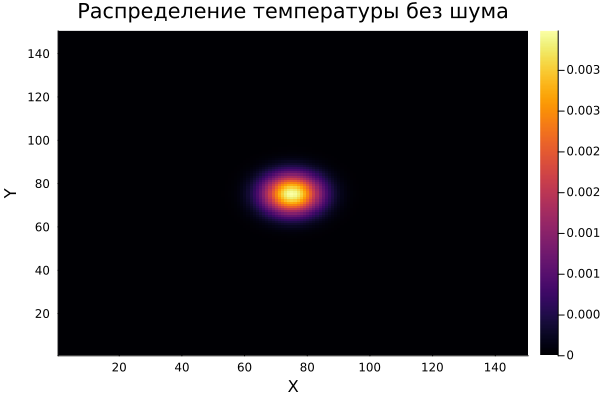

In [54]:
p = simulate_heat_conduction(N, steps, kappa)
display(p)

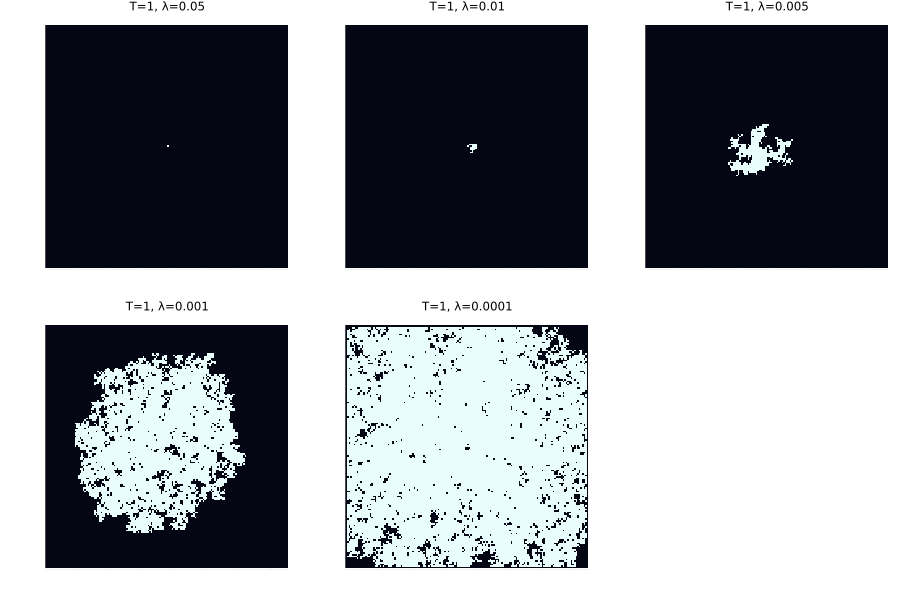

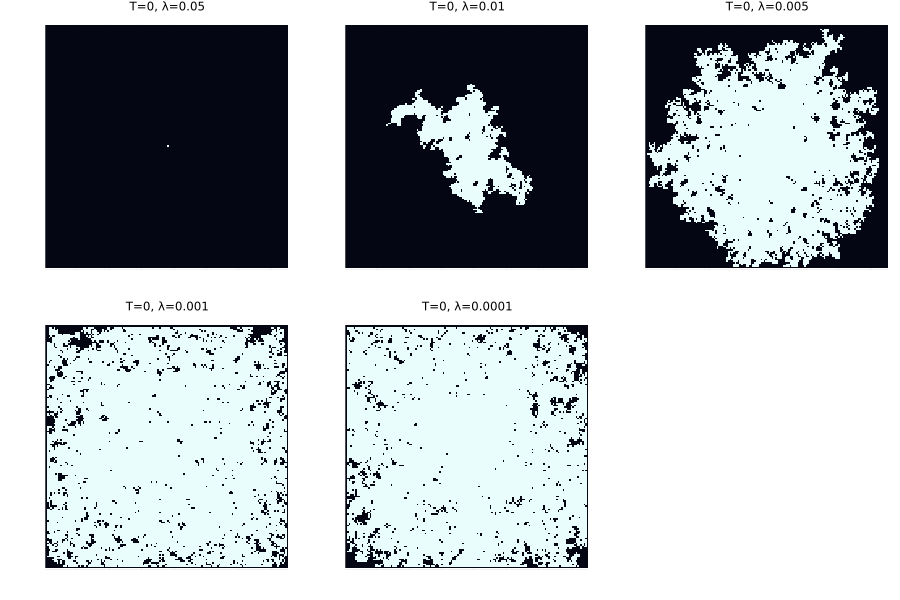

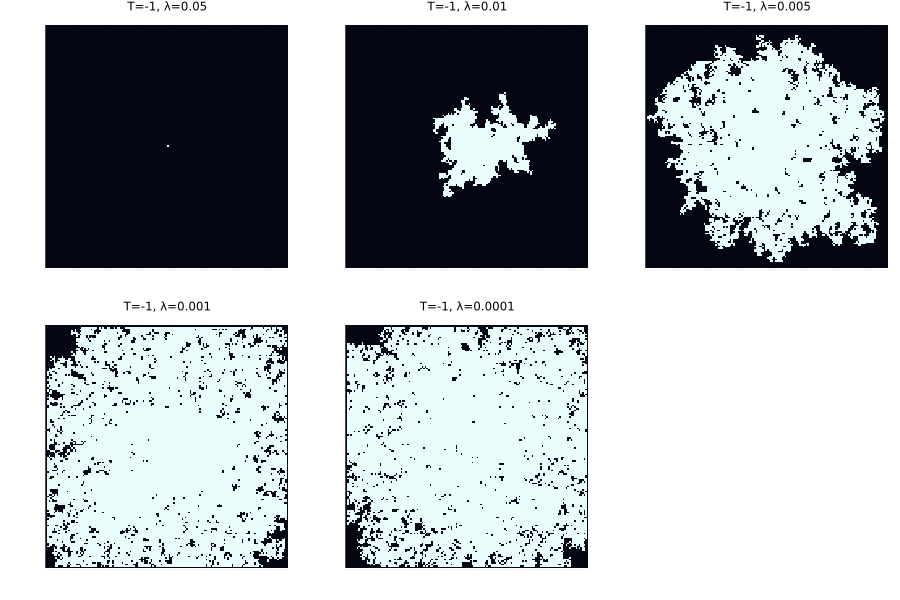

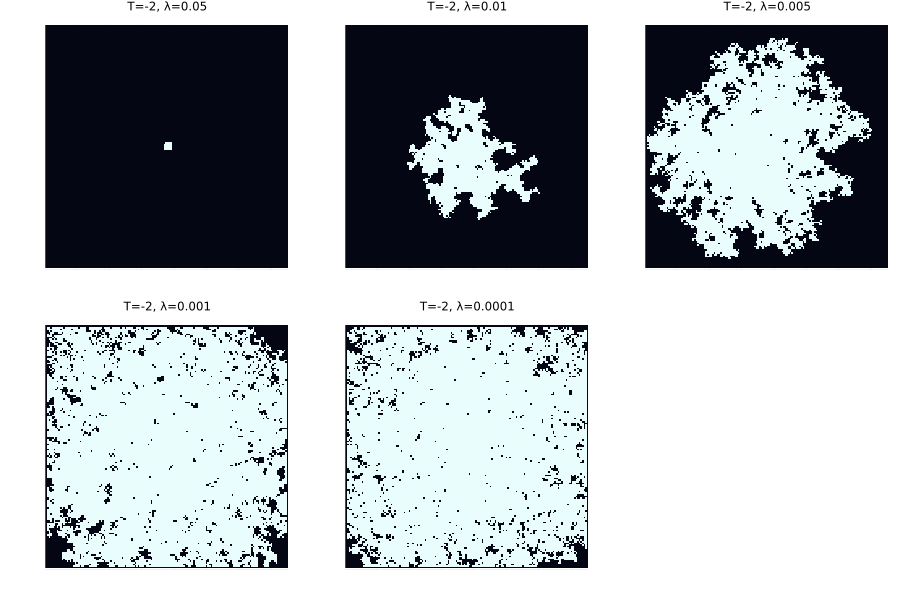

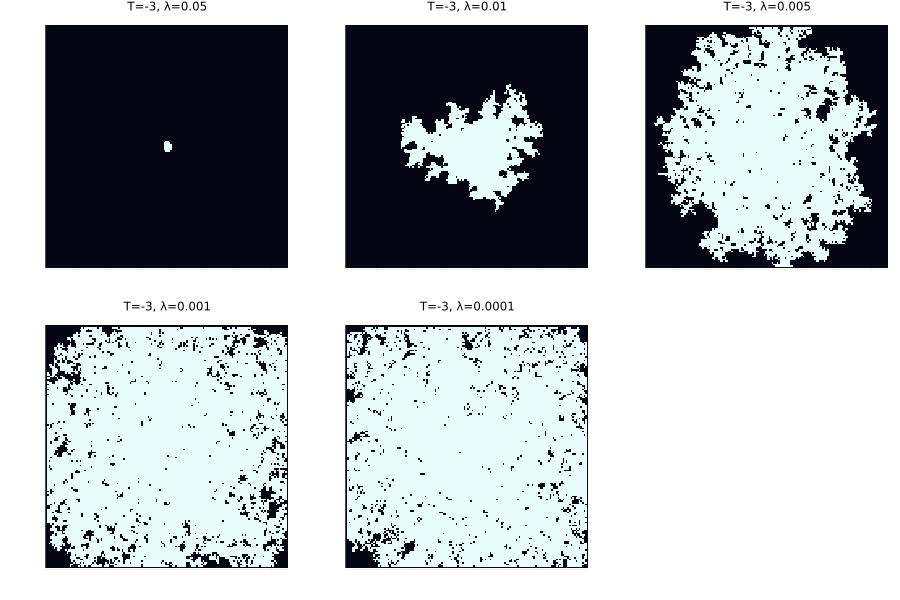

In [55]:
using Plots, LinearAlgebra, Statistics

N = 150
steps = 100
kappa = 0.1
w = 0.5
T_m = 0
delta = 0.02
dt = 1
h = 1

temp_values = [1, 0, -1, -2, -3]
lambda_values = [0.05, 0.01, 0.005, 0.001, 0.0001]

for (idx, T_init) in enumerate(temp_values)
    
    plots_list = []
    
    for l in lambda_values
        T_grid = zeros(N, N)
        n_grid = zeros(Int, N, N)
        T_grid[N÷2+1, N÷2+1] = T_init
        n_grid[N÷2+1, N÷2+1] = 1

        _, _, _, n_final = simulate_solidification(T_grid, n_grid, steps, w, kappa, dt, h, delta, T_m, l)
        
        p = heatmap(n_final, 
                    c = :ice, 
                    title = "T=$T_init, λ=$l", 
                    titlefontsize = 8,
                    legend = false, 
                    axis = false, 
                    aspect_ratio = :equal)
        push!(plots_list, p)
    end
    
    fig = plot(plots_list..., layout = (2, 3), size = (900, 600))
    display(fig)
        savefig("Resultats_T_$(T_init).png")
end


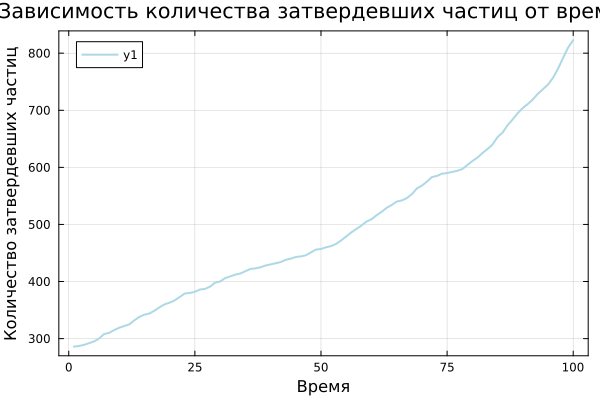

In [60]:
using Plots

# 1. On récupère les données de la simulation
# (Assurez-vous d'avoir déjà lancé solid_counts, ..., = simulate_solidification(...))
temps = 1:length(solid_counts)

# 2. On trace le graphique avec les paramètres de style de l'image
plot(temps, solid_counts,
    title = "Зависимость количества затвердевших частиц от времени",
    xlabel = "Время",
    ylabel = "Количество затвердевших частиц",
    label = "y1",             # Nom de la légende comme sur l'image
    color = :lightblue,       # Couleur bleu clair
    linewidth = 2,            # Épaisseur de la ligne
    legend = :topleft,        # Position de la légende en haut à gauche
    grid = true,              # Afficher la grille grise
    framestyle = :box,        # Encadrer le graphique
    size = (600, 400)         # Taille de l'image
)


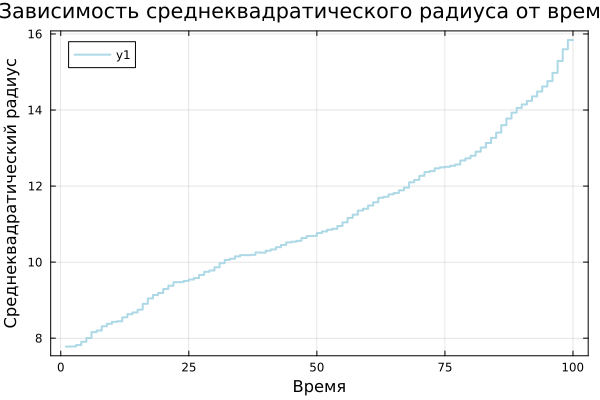

In [61]:
using Plots

# 1. On utilise le vecteur mean_radii issu de votre simulation
# (Assurez-vous d'avoir lancé la simulation juste avant)
temps = 1:length(mean_radii)

# 2. Création du graphique du rayon quadratique moyen
plot(temps, mean_radii,
    title = "Зависимость среднеквадратического радиуса от времени",
    xlabel = "Время",
    ylabel = "Среднеквадратический радиус",
    label = "y1",
    color = :lightblue,
    linewidth = 2,
    linetype = :steppre,    # Pour garder l'effet d'escalier physique
    legend = :topleft,
    grid = true,
    framestyle = :box,
    size = (600, 400)
)


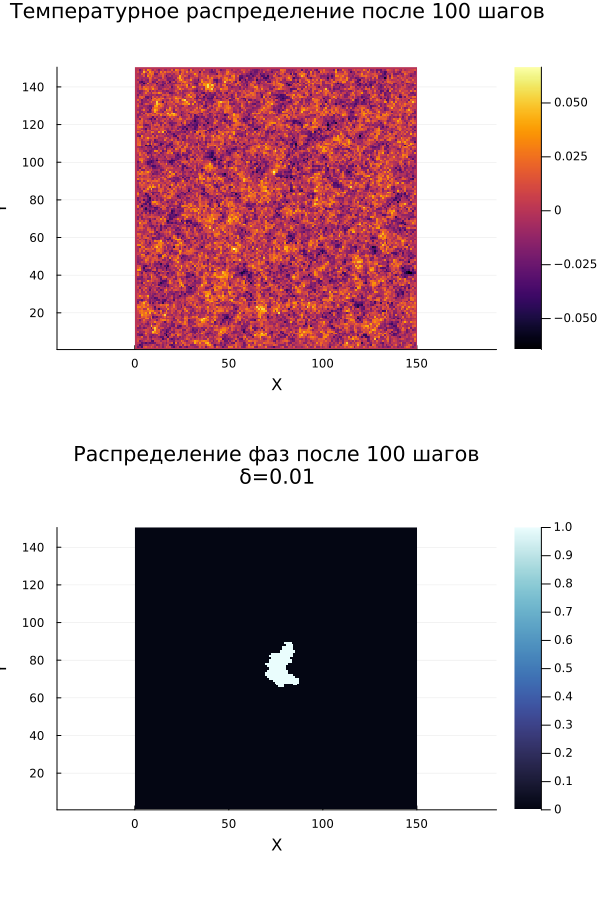

In [62]:
using Plots

# 1. Запускаем симуляцию (убедитесь, что delta = 0.01)
# Нам нужны матрицы T (температура) и n (состояние фаз)
solid_counts, mean_radii, fractal_dims, final_n = simulate_solidification(T, n, 100, w, kappa, dt, h, 0.01, T_m, lambda)

# 2. График распределения температуры (Рис. 11)
p11 = heatmap(T, 
    c = :inferno,          # Цветовая схема как на фото
    title = "Температурное распределение после 100 шагов",
    xlabel = "X", ylabel = "Y",
    aspect_ratio = :equal)

# 3. График распределения фаз (Рис. 12)
# final_n содержит 0 для жидкости и 1 для твердого тела
p12 = heatmap(final_n, 
    c = :ice,              # Темный фон, светлый кристалл
    title = "Распределение фаз после 100 шагов\nδ=0.01",
    xlabel = "X", ylabel = "Y",
    aspect_ratio = :equal)

# 4. Вывод обоих графиков в один столбец
plot(p11, p12, layout = (2, 1), size = (600, 900))


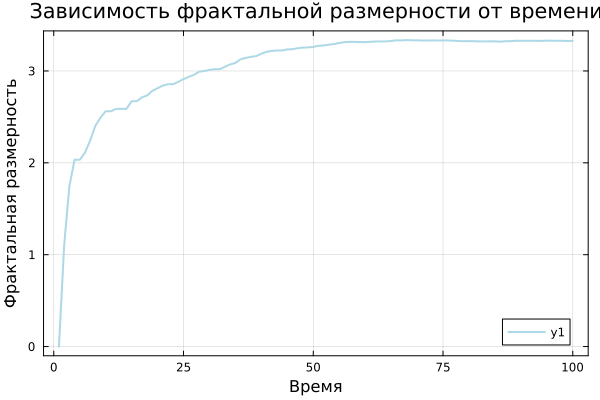

In [63]:
using Plots

# 1. Используем данные из симуляции
времени = 1:length(fractal_dims)

# 2. Построение графика фрактальной размерности
plot(времени, fractal_dims,
    title = "Зависимость фрактальной размерности от времени",
    xlabel = "Время",
    ylabel = "Фрактальная размерность",
    label = "y1",
    color = :lightblue,
    linewidth = 2,
    legend = :bottomright,    # На Рис. 9 легенда находится внизу справа
    grid = true,
    framestyle = :box,
    size = (600, 400)
)


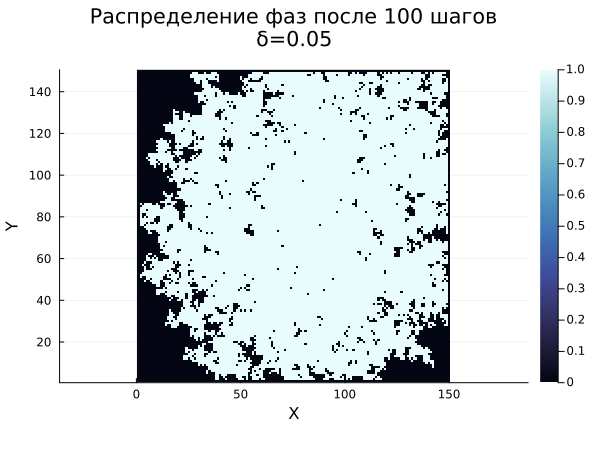

In [64]:
using Plots

# 1. Устанавливаем высокое значение шума (0.05 или 0.1 как на Рис. 13)
delta_high = 0.05 

# 2. Запускаем симуляцию на 100 шагов
_, _, _, n_noisy = simulate_solidification(T, n, 100, w, kappa, dt, h, delta_high, T_m, lambda)

# 3. Визуализация распределения фаз
heatmap(n_noisy, 
    c = :ice, 
    title = "Распределение фаз после 100 шагов\nδ=$delta_high",
    xlabel = "X", 
    ylabel = "Y",
    legend = true,          # На фото есть цветовая шкала справа
    aspect_ratio = :equal,
    size = (600, 450)
)
